In [ ]:
import commNumWL
import importlib
importlib.reload(commNumWL)
from commNumWL import Modem, Mesure, Source, Canal
import matplotlib.pyplot as plt
import numpy as np
from scapy.all import Ether

Flushing input history
Flushing output cache (0 entries)


## Classe Source ##

### Méthode random

In [3]:
#Création d'un vecteur de bit générés aléatoirement grâce à la métohde random
vect_bit = Source.random(20)
print(f'Vecteur de bits générés aléatoirement:\n{vect_bit}')

Vecteur de bits générés aléatoirement:
[0 0 0 0 1 0 1 0 0 0 0 1 1 1 0 0 0 0 0 1]


### Méthode ICMP ###

In [4]:
#Création d'une trame ICMP grâce à la méthode icmp
Paquet_ICMP = Source.icmp('192.168.1.2')
print('Les données associées à la trame au format binaire:\n', Paquet_ICMP)

Les données associées à la trame au format binaire:
 [0 0 0 0 0 1 1 0 0 0 0 0 0 1 1 1 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 1
 0 1 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0
 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 1 1 1 1 1 0 1 1 1 1 0 0 0 1 1 0 0 1 1 0 0 0 0 0 0 1 0 1 0 1 0
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0
 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 1 1 1
 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0]


# Émetteur PAM4 #

Les deux blocs nécéssaire pour un émetteur dans une chaine de transmission numérique sont le bloc de Mapping et le le bloc de Filtre de mise en forme.

### Signal PAM4 avec 20 symbole aléatoires ###

In [5]:
#Génération d'une séquence binaire pseudo aléatoire sur 20 bits
bits = Source.random(20)
print(f'Le vecteur bits est:\n{bits}\n')

#Création d'un objet nommé modemPAM4 par instantiation de la classe Modem
modemPAM4 = Modem('PAM', 4, bits)

#Visualisation d'attributs de l'objet modemPAM4 (créés dans le constructeur)
print(f'La matrice des symboles numériques est:\n{modemPAM4.symbs_num}\n')

#Application d'un maping sur la séquence binaire grâce à une methode
Symbs_mod = modemPAM4.mapping(3)
print(f'Le vecteur des symboles de modulation symbs_mod est:\n{Symbs_mod}')

Le vecteur bits est:
[1 0 1 0 0 1 0 1 0 1 0 0 1 1 0 1 1 0 0 0]

La matrice des symboles numériques est:
[[1 0]
 [1 0]
 [0 1]
 [0 1]
 [0 1]
 [0 0]
 [1 1]
 [0 1]
 [1 0]
 [0 0]]

Le vecteur des symboles de modulation symbs_mod est:
[ 1  1 -1 -1 -1 -3  3 -1  1 -3]


### Diagramme de constellation ###

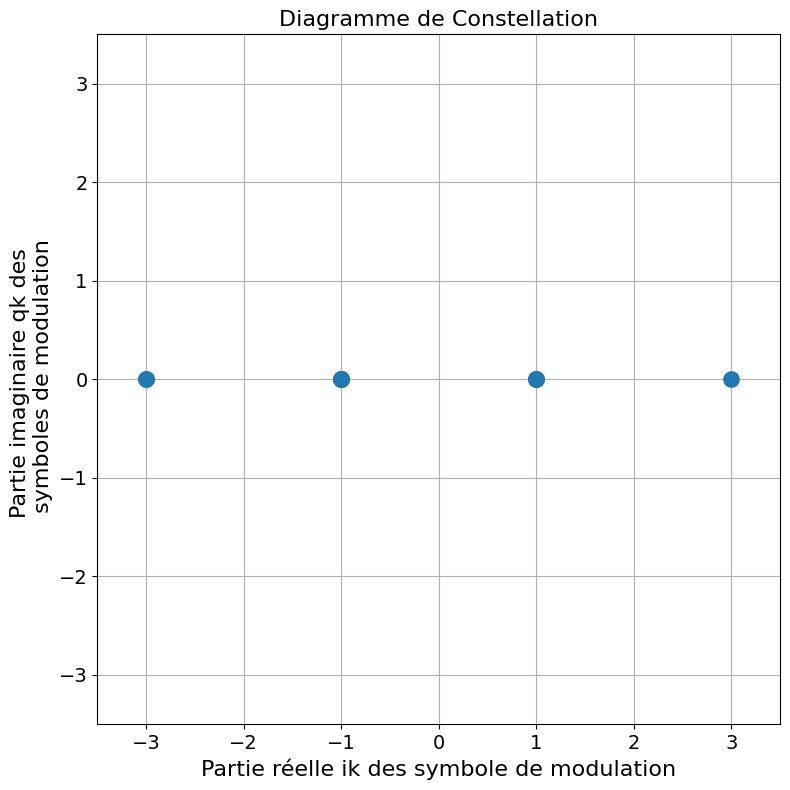

In [6]:
#Tracé du diagramme de constellation des symboles modulés grâce à la methode constellation
Mesure.constellation(Symbs_mod)

Symboles de modulation:
[ 1  1 -1 -1 -1 -3  3 -1  1 -3]

Signal PAM4 avec filtre de mise en forme rectangulaire (NRZ):
[ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -3 -3 -3 -3 -3 -3 -3 -3
  3  3  3  3  3  3  3  3 -1 -1 -1 -1 -1 -1 -1 -1  1  1  1  1  1  1  1  1
 -3 -3 -3 -3 -3 -3 -3 -3]



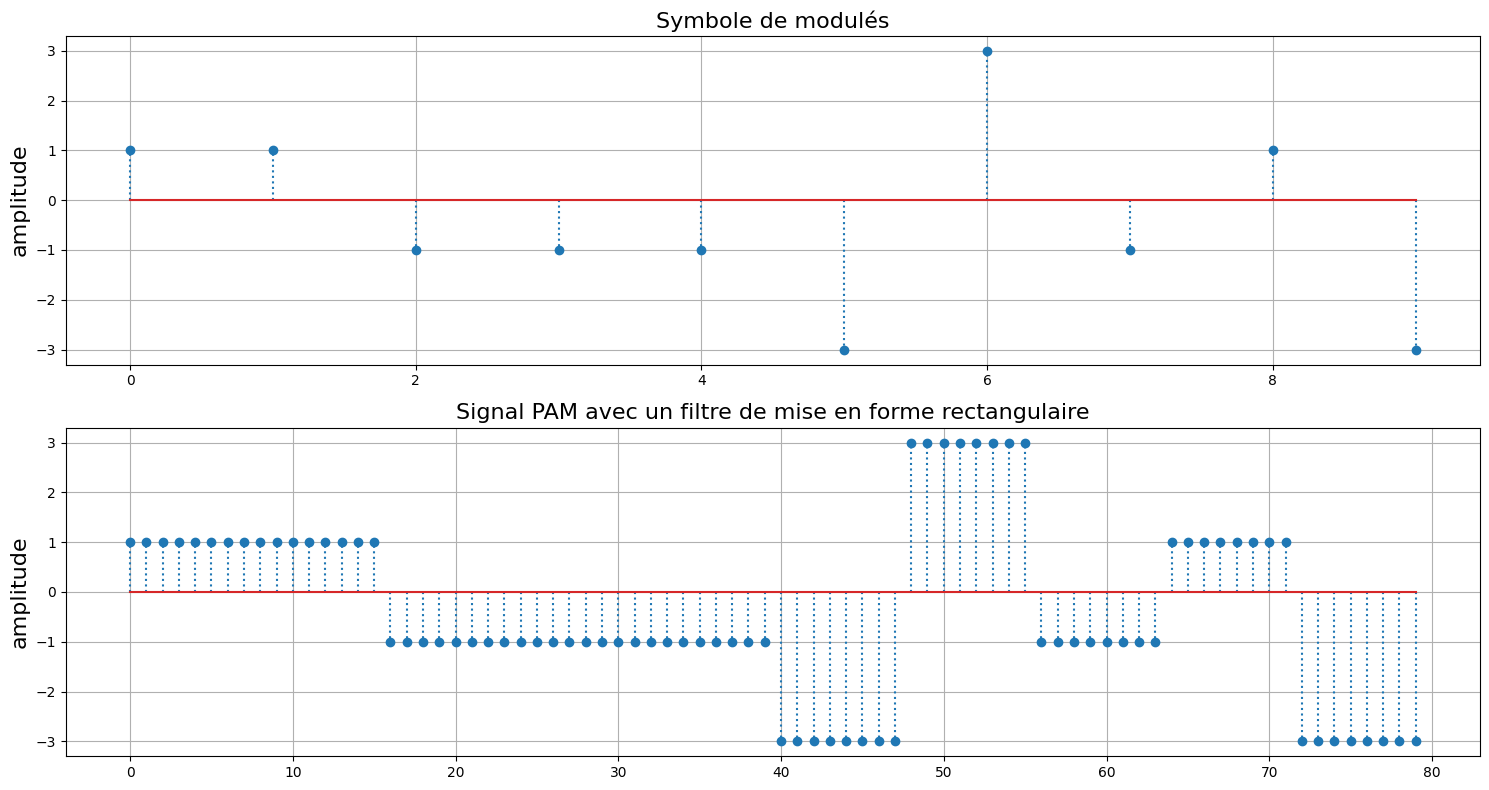

In [7]:
#Génération du signal PAM4 grâce à un filtre de mis en forme
PAM4 = modemPAM4.filtre_MF(Symbs_mod, 8)
print(f'Symboles de modulation:\n{Symbs_mod}\n')
print(f'Signal PAM4 avec filtre de mise en forme rectangulaire (NRZ):\n{PAM4}\n')

#Vecteur d'échantillons
t1 = np.arange(0, len(Symbs_mod))
t2 = np.arange(0, len(PAM4))

#Affichage des symboles de modulés puis du signal PAM4 après filtre de mis en forme
fig, ax = plt.subplots(2, 1, figsize = (15,8))

ax[0].stem(t1 , Symbs_mod, ':o')
ax[0].set_title('Symbole de modulés', fontsize = 16)
ax[0].set_ylabel('amplitude', fontsize = 16)
ax[0].grid()
ax[1].stem(t2, (PAM4), ':o')
ax[1].grid()
ax[1].set_title('Signal PAM avec un filtre de mise en forme rectangulaire', fontsize = 16)
ax[1].set_ylabel('amplitude', fontsize = 16)

plt.tight_layout()

## Canal AWGN ##

Le canal **AWGN** est un canal de transmission ajoutant un bruit blanc gaussien au signal émis. Il permet de modéliser des processus aléatoires qui se produisent dans la nature comme le bruit thermique dans les conducteurs, ou les sources célestes comme le Soleil.

Le terme **AWGN** indiquent que le bruit est :
* Additif : il s'ajoute au signal
* Blanc: sa puissance est uniforme sur toute la largeur de bande de fréquences du système
* Gaussien : il a distribution normale ou gaussienne dans le domaine temportel


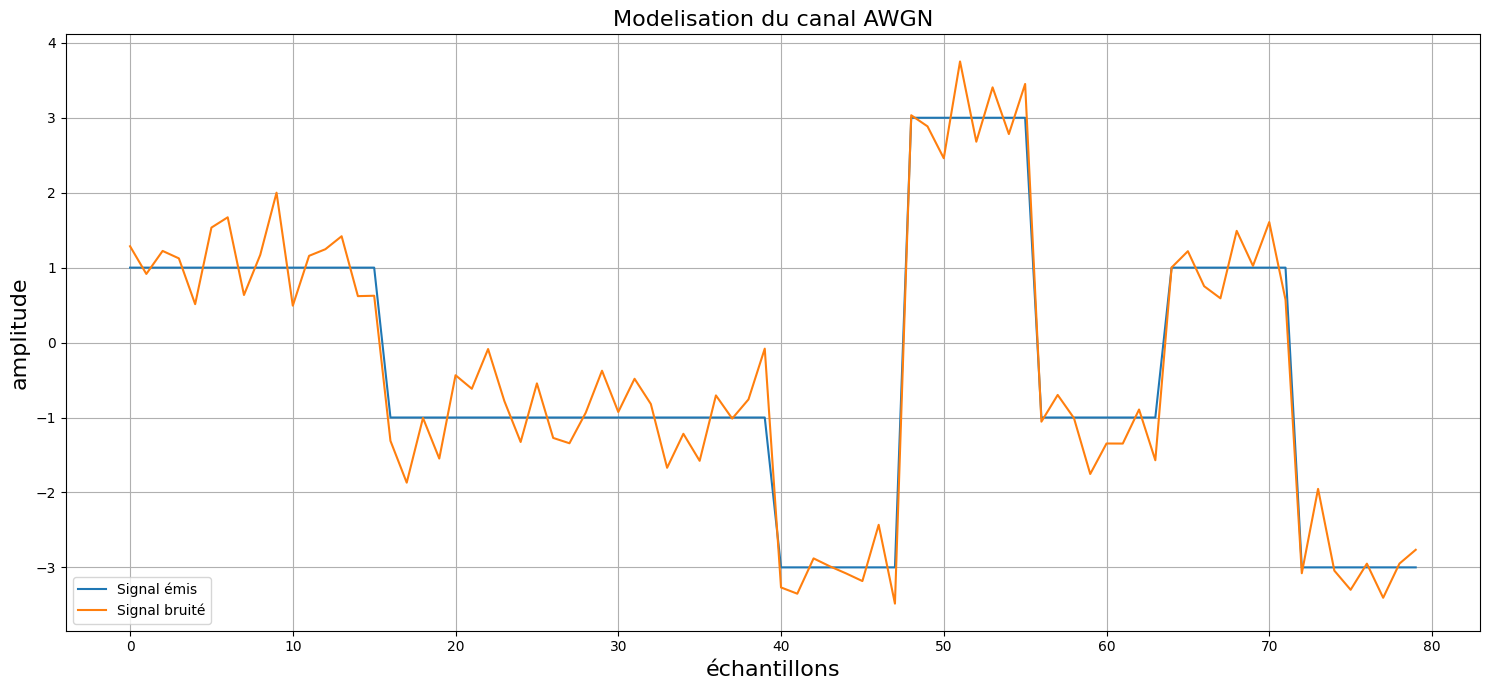

In [8]:
#Modélisation du canal AWGN grâce à la methode statique awgn de le classe Canal
signal_bruite = Canal.awgn(PAM4, 0, 0.5)

#Vecteur d'échantillons
t = np.arange(0, len(signal_bruite))

#Affichage du signal PAM4 et de ce même signal bruité
fig, ax = plt.subplots(figsize = (15, 7))

ax.plot(t, PAM4, label = 'Signal émis')
ax.set_title('Modelisation du canal AWGN', fontsize = 16)
ax.plot(t, signal_bruite, label = 'Signal bruité')
ax.set_xlabel('échantillons', fontsize = 16)
ax.set_ylabel('amplitude', fontsize = 16) 
ax.grid()

plt.legend(loc = 'lower left')
plt.tight_layout()

## Récepteur PAM4 ##

Les deux blocs nécéssaire pour un récepteur dans une chaine de transmission numérique sont le bloc de filtre de réception et le bloc de décision sur le symbole et démapping.

### Downsample ###

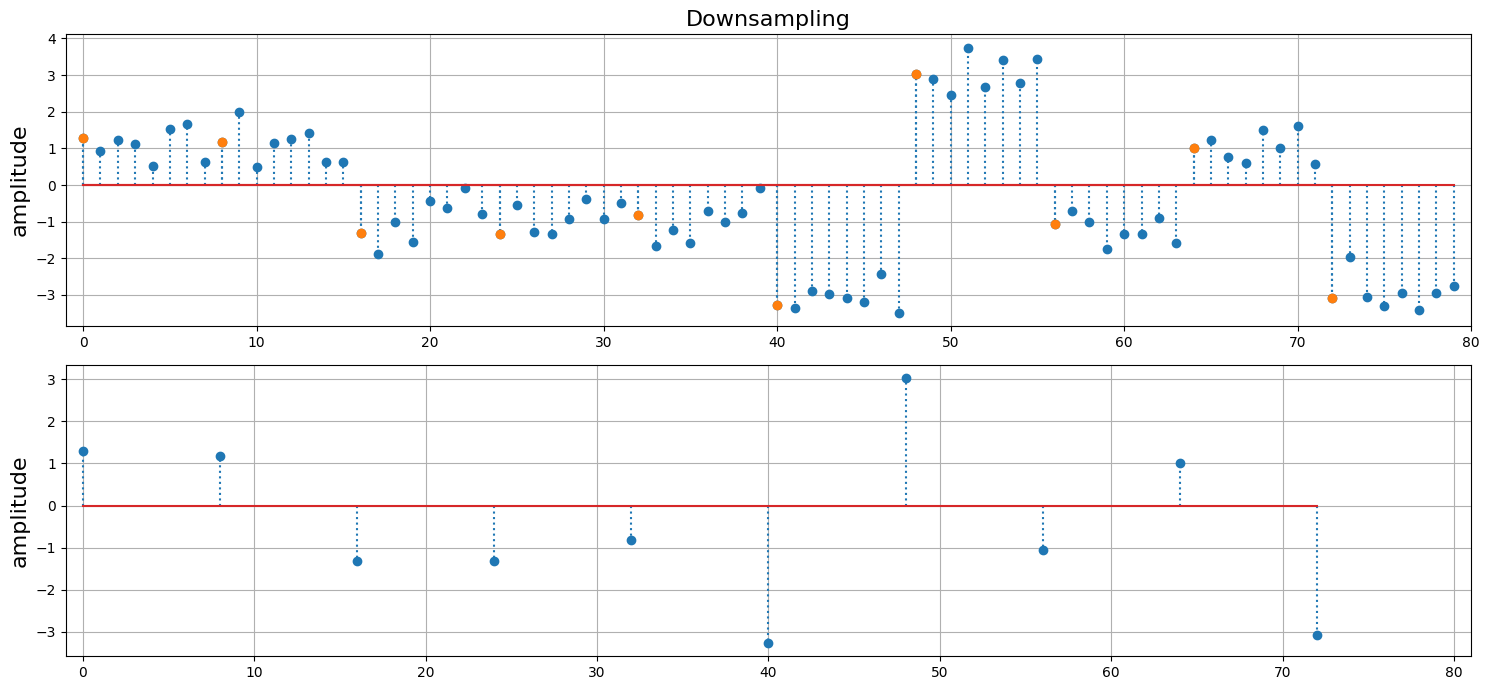

In [9]:
#Declaration de l'offset et du facteur de downsampling du signal PAM4 reçue
offset = 0
downsampling = 8

#Passage du signal pseudo-continu aux symboles de modulation
Symbs_rcv = modemPAM4.downsample(signal_bruite, downsampling, offset)

#Vecteur d'échantillons
t1 = np.arange(0, len(signal_bruite))
t2 = np.arange(offset, len(signal_bruite), downsampling)

#Affichage 
fig, ax = plt.subplots(2, 1, figsize = (15, 7))

ax[0].stem(t1, signal_bruite, ':o')
ax[0].stem(t2, Symbs_rcv, ':o')
ax[0].set_title('Downsampling', fontsize = 16)
ax[0].set_ylabel('amplitude', fontsize = 16)
ax[0].set_xlim(-1, 80)
ax[0].grid()

ax[1].stem(t2, Symbs_rcv, ':o')
ax[1].set_ylabel('amplitude', fontsize = 16)
ax[1].set_xlim(-1, 81)
ax[1].grid() 

plt.tight_layout()

### Détéction ###

Les symboles reçues sont:
[ 1.28533926  1.17042996 -1.31111025 -1.32678987 -0.8196509  -3.26787366
  3.03359141 -1.05574083  1.00165845 -3.07822548]

Après calcul de distance, les symboles détectés sont: 
[ 1  1 -1 -1 -1 -3  3 -1  1 -3]

Les symboles émis sont:
[ 1  1 -1 -1 -1 -3  3 -1  1 -3]


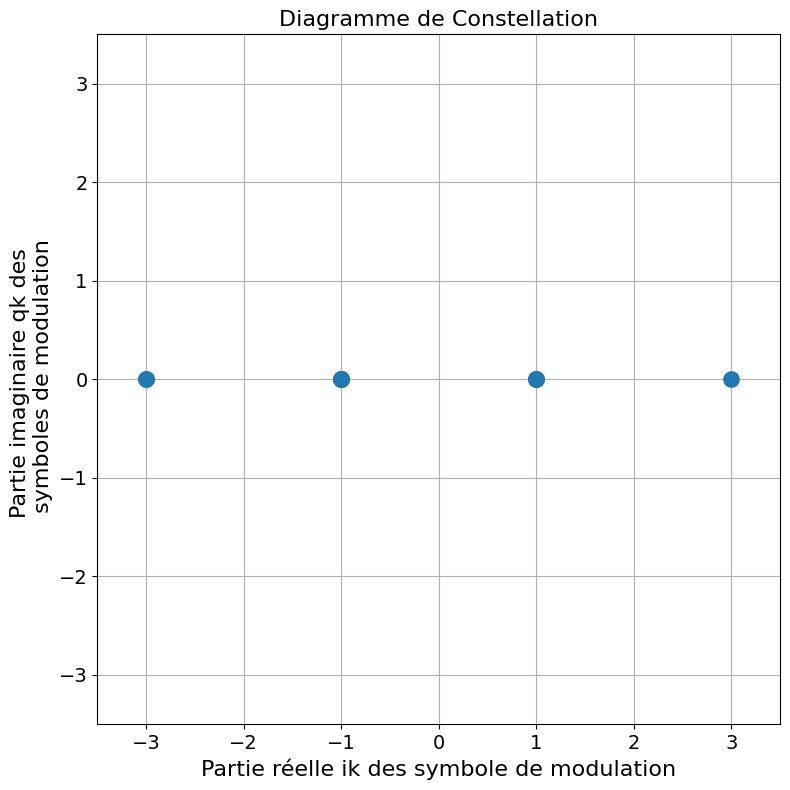

In [10]:
Symbs_detect = modemPAM4.detection(Symbs_rcv)
print(f'Les symboles reçues sont:\n{Symbs_rcv}')
print(f'\nAprès calcul de distance, les symboles détectés sont: \n{Symbs_detect}')
print(f'\nLes symboles émis sont:\n{Symbs_mod}')
Mesure.constellation(Symbs_detect)

### Demapping ###

In [11]:
Bits_rcv = modemPAM4.demapping(Symbs_detect)
print(f'Les bits reçues sont:\n{Bits_rcv}')
print(f'\nLes bits émis sont:\n{bits}')

Les bits reçues sont:
[1 0 1 0 0 1 0 1 0 1 0 0 1 1 0 1 1 0 0 0]

Les bits émis sont:
[1 0 1 0 0 1 0 1 0 1 0 0 1 1 0 1 1 0 0 0]


In [12]:
####################################################################
########### Caractéristiques de la transmission ####################
####################################################################
#Emetteur


#Canal


#Récepteur


####################################################################
############                  Emmeteur                 #############
####################################################################
#Sources
Trame_ICMP = Source.icmp('8.8.8.8', '192.168.10.4')

#Création et initialisation des paramètres du modem (création de l'objet)
modemPAM4 = Modem('PAM', 4, Trame_ICMP)

#Mapping
Symbs_mod2 = modemPAM4.mapping(3)

#Filtre de mise en forme
Signal = modemPAM4.filtre_MF(Symbs_mod2, 8)

####################################################################
############                 Canal AWGN               ##############
####################################################################
Signal_bruite = Canal.awgn(Signal, 0, 0.5)

####################################################################
############                 Récepteur               ###############
####################################################################
#Downsampling
Symbs_rcv = modemPAM4.downsample(Signal_bruite, 8, 0)

#Détection
Symbs_detect = modemPAM4.detection(Symbs_rcv)

#Démapping
Trame_ICMP_rcv = modemPAM4.demapping(Symbs_detect)

Trame_decode = Source.decodage(Trame_ICMP_rcv)

# Mesure.dsp(Trame_ICMP_rcv)

####################################################################
############                 Affichage               ###############
####################################################################
print(f'Les bits émis sont:\n{Trame_ICMP}\n')
print (f'Les bits reçues sont:\n{Trame_ICMP_rcv}\n')
print(f'La trame ICMP décodé est:\n')
Trame_decode.show()


Les bits émis sont:
[0 0 0 0 0 1 1 0 0 0 0 0 0 1 1 1 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 1
 0 1 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0
 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 0 1 0 0 1 0 0 1 1 0 0 0 0 0 0 1 0 1 0 1 0
 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 1 1 1
 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0]

Les bits reçues sont:
[0 0 0 0 0 1 1 0 0 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 1
 0 1 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0
 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 